In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
import os
os.getcwd()

'/Users/chux/Desktop/reflectorModel'

In [4]:
from synclinemodel import synclinemodel
from afd_explode import afd_explode

In [5]:
# ── Model parameters ──────────────────────────────────────────────────────────
dx        = 5       # grid spacing (m)
xmax      = 2000    # max x (m)
zmax      = 1000    # max z (m)
vhigh     = 4000    # velocity below syncline (m/s)
vlow      = 2000    # velocity above syncline (m/s)
zsyncline = 300     # depth to flat interface (m)
zfocal    = 100     # depth to focal point of syncline (m)
radius    = 500     # radius of syncline semi-circle (m)
            # NOTE: radius + zfocal (600) > zsyncline (300) → syncline exists

In [6]:
# ── Build model ───────────────────────────────────────────────────────────────
vel, x, z = synclinemodel(dx, xmax, zmax, vhigh, vlow,
                           zsyncline=zsyncline, radius=radius, zfocal=zfocal)

print(f"Velocity model shape : {vel.shape}  (nz={len(z)}, nx={len(x)})")
print(f"Velocity range       : {vel.min():.0f} – {vel.max():.0f} m/s")

Velocity model shape : (201, 401)  (nz=201, nx=401)
Velocity range       : 2000 – 4000 m/s


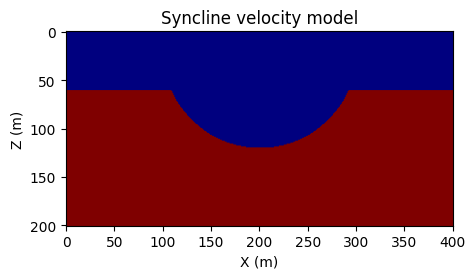

In [7]:
fig=plt.figure(figsize=[5,5])

# Left: raw velocity
#im0 = plt.imshow(vel, extent=[x[0], x[-1], z[-1], z[0]],
#                     aspect='auto', cmap='jet')
im0 = plt.imshow(vel, cmap='jet')
#plt.colorbar(im0, label='Velocity (m/s)')
plt.title('Syncline velocity model')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.show()
#plt.tight_layout()

In [8]:
from ricker import ricker

In [9]:
dt=.004
dtstep=.0005
tmax=1.5
#wavelet
src,tw=ricker(dt,10,0.2)

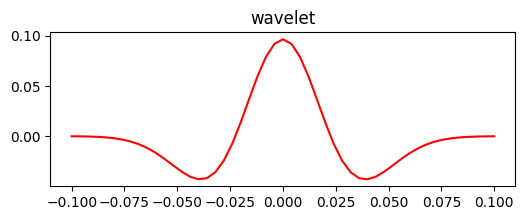

In [10]:
fig1=plt.figure(figsize=[6,2])
plt.plot(tw,src,'r')
plt.title('wavelet')
plt.show()

In [11]:
type(x)

numpy.ndarray

In [12]:
xrec=x
zrec=x*0

In [13]:
vel.shape

(201, 401)

In [14]:
seis1,seis_unfiltered,t=afd_explode(dx,dtstep,dt,tmax,vel,xrec,zrec,src,tw,2);

len(tw) is  51
len(wlet)is  51
There are 3000 steps to complete.
  wavefield propagated to 0.0605 s; time left ≈ 3.7 s
  wavefield propagated to 0.1210 s; time left ≈ 3.1 s
  wavefield propagated to 0.1815 s; time left ≈ 2.8 s
  wavefield propagated to 0.2420 s; time left ≈ 2.6 s
  wavefield propagated to 0.3025 s; time left ≈ 2.4 s
  wavefield propagated to 0.3630 s; time left ≈ 2.2 s
  wavefield propagated to 0.4235 s; time left ≈ 2.1 s
  wavefield propagated to 0.4840 s; time left ≈ 2.0 s
  wavefield propagated to 0.5445 s; time left ≈ 1.9 s
  wavefield propagated to 0.6050 s; time left ≈ 1.7 s
  wavefield propagated to 0.6655 s; time left ≈ 1.6 s
  wavefield propagated to 0.7260 s; time left ≈ 1.5 s
  wavefield propagated to 0.7865 s; time left ≈ 1.3 s
  wavefield propagated to 0.8470 s; time left ≈ 1.2 s
  wavefield propagated to 0.9075 s; time left ≈ 1.1 s
  wavefield propagated to 0.9680 s; time left ≈ 1.0 s
  wavefield propagated to 1.0285 s; time left ≈ 0.9 s
  wavefield propa

In [15]:
seis1.shape

(376, 401)

In [16]:
smin,smax=np.percentile(seis1,[1,99])

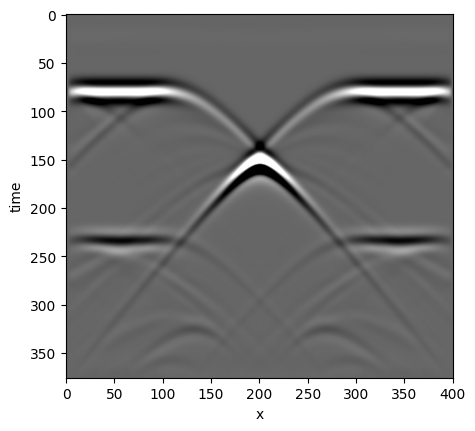

In [17]:
fig2=plt.figure(figsize=[5,5])
plt.imshow(seis1, cmap='gray', vmin=smin, vmax=smax)
plt.xlabel('x')
plt.ylabel('time')
plt.show()